## Preprocessing code

In this notebook ill hold all code to do with combinning both the LSTM approach witht he gaussian mixture, instead of trying to have the LSTM differenciate between different types of swings instea dill have it find swing or Noswing / Idle and then use a GMM to classify what kind of swing has been identified 
* Extracting Pose data from video files
* Dataset Augmentations
* Sanity testing extraction pipeline


Links:
* PyTorch LSTM : docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html

In [49]:
import os
import ast 
import json
import torch
import shutil
import random
import cv2 as cv
import numpy as np
import pandas as pd
import torch.nn as nn
# import mediapipe as mp
import matplotlib.pyplot as plt

from tqdm import tqdm
from joblib import dump, load
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# Custom classes
from classes.GraphPlotting import GraphPlotter


RANDOM_STATE = 42

# Global vars ill use throughout the file
SWING_TYPES = ['Backhand', 'Forehand', 'NoStroke', 'Serves']

BINARY_SWING_DICT = {
        "Backhand": 0,
        "Forehand": 0,
        "NoStroke": 1,
        "Serves": 0
    }


KEYPOINTS = ['NOSE','LEFT_EYE_INNER','LEFT_EYE', 'LEFT_EYE_OUTER', 'RIGHT_EYE_INNER', 'RIGHT_EYE', 'RIGHT_EYE_OUTER', 'LEFT_EAR','RIGHT_EAR','MOUTH_LEFT', 'MOUTH_RIGHT', 'LEFT_SHOULDER','RIGHT_SHOULDER','LEFT_ELBOW','RIGHT_ELBOW','LEFT_WRIST','RIGHT_WRIST', 'LEFT_PINKY', 'RIGHT_PINKY', 'LEFT_INDEX', 'RIGHT_INDEX', 'LEFT_THUMB', 'RIGHT_THUMB', 'LEFT_HIP','RIGHT_HIP','LEFT_KNEE','RIGHT_KNEE','LEFT_ANKLE','RIGHT_ANKLE', 'LEFT_HEEL', 'RIGHT_HEEL', 'LEFT_FOOT_INDEX', 'RIGHT_FOOT_INDEX'] 

Loading my GPU

In [50]:
# Test I can see gpu
gpu_visible = torch.cuda.is_available()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Is my GPU visible to train on :', gpu_visible)
print('Using device:', device)
print()

# Gpu stats and optimisations 
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')
    # Making deterministic
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# No random variability
random.seed(RANDOM_STATE); 
np.random.seed(RANDOM_STATE); 
torch.manual_seed(RANDOM_STATE); 

Is my GPU visible to train on : True
Using device: cuda

NVIDIA GeForce RTX 3070
Memory Usage:
Allocated: 0.0 GB
Cached:    0.1 GB


Utility functions that I use throughout this script

In [42]:
def pretty_print_json(dict_object: object):
    ''' Makes JSON object prettier for being printed 
    '''
    json_object = json.dumps(dict_object)
    parsed_json = json.loads(json_object) 
    print(json.dumps(parsed_json, indent=4))


def save_JSON_object(json_path: str, json_object: object):
    ''' Saves a JSON Object to a path
    '''
    with open(json_path, 'w') as outfile:
        json.dump(json_object, outfile)


def load_JSON_object(json_path: str):
    ''' Loads JSON object from a file
    '''
    with open(json_path, "r") as f:
        json_data = json.load(f)
        return json_data


def create_folder(folder_name: str):
    '''Used to create folders
    '''
    if not os.path.exists(folder_name):
        os.mkdir(folder_name)


def save_torch_model(model, save_folder: str ='models/', file_name: str = None):
    ''' Saves torch models 
    Args:
        model (nn) : Model to be saved 
        save_folder (String) : String file path to folder where all models will be saved 
        file_name (String) : Name to save model as
    '''
    create_folder(save_folder)
    torch.save(model.state_dict(), f'{save_folder}{file_name}.pth')


Convert all JSON files to pd.DataFrames so that theyre easier to manipulate

## Overall plan:
* compute all my features
* Split dataset into train / val /test

#### Train the GMM:
* Do PCA same as Gaussian notebook
* Fit scaler on train for GMM
* train GMM on train only (Results might be worse since now have to create val set as well as test for less samples to train on)
* train GMM on swings only or still include noStroke incase LSTM gets it wrong?

#### Train the LSTM:
* Train LSTM on train and val like before 
* Shold get around 85% accuracy 

#### Inference:
* Run the LSTM on a video sequence
* If it detects a swing the pass the raw data to the GMM where it will be scaled using the GMM training scaler and the the swing classified

In [74]:
def create_pose_df(json_data:object):
    ''' Create a DataFrame that more mutable for generating features
    Args:
        json_data
    '''
    pose_data_dict = {f"{kp}_{axis}": [] for kp in KEYPOINTS for axis in ("X", "Y", "Z")}

    for index, frame_data in enumerate(json_data['list_body_part_points']):
        for keypoint_dict in frame_data['key_points']:
            for axis in ['x', 'y', 'z']:
                pose_data_dict[f'{keypoint_dict["part"]}_{axis.upper()}'].append(keypoint_dict[axis])
            
    df = pd.DataFrame(pose_data_dict)
    return df



def generate_extra_keypoints(df:pd.DataFrame):
    ''' 
    '''
    # Calcualte center of hips
    df['MID_HIP_X'] = (df['RIGHT_HIP_X'] + df['LEFT_HIP_X']) / 2
    df['MID_HIP_Y'] = (df['RIGHT_HIP_Y'] + df['LEFT_HIP_Y']) / 2
    df['MID_HIP_Z'] = (df['RIGHT_HIP_Z'] + df['LEFT_HIP_Z']) / 2
    # calculate center of shoulders
    df['MID_SHOULDER_X'] = (df['RIGHT_SHOULDER_X'] + df['LEFT_SHOULDER_X']) / 2
    df['MID_SHOULDER_Y'] = (df['RIGHT_SHOULDER_Y'] + df['LEFT_SHOULDER_Y']) / 2
    df['MID_SHOULDER_Z'] = (df['RIGHT_SHOULDER_Z'] + df['LEFT_SHOULDER_Z']) / 2
    # Calculate center torso
    df['MID_CENTER_TORSO_X'] = (df['RIGHT_HIP_X'] + df['MID_SHOULDER_X']) / 2
    df['MID_CENTER_TORSO_Y'] = (df['RIGHT_HIP_Y'] + df['MID_SHOULDER_Y']) / 2
    df['MID_CENTER_TORSO_Z'] = (df['RIGHT_HIP_Z'] + df['MID_SHOULDER_Z']) / 2
    return df



def translational_invariance(df:pd.DataFrame, center_point:str ="NOSE"):
    ''' Spatially align the skeleton by re-centering all keypoints around a chosen point.
    Args:
        center_point (str): The keypoint used as the origin (default: "NOSE").
    Returns:
        pd.DataFrame: DataFrame with translationally invariant pose data.
    '''
    # Extract center coordinates
    cx = df[f"{center_point}_X"]
    cy = df[f"{center_point}_Y"]

    # Subtract center from all X and Y coordinate columns
    for col in df.columns:
        if col.endswith("_X"):
            df[col] = df[col] - cx
        elif col.endswith("_Y"):
            df[col] = df[col] - cy

    return df



def generate_deltas(df:pd.DataFrame):
    ''' Calculate the movement of each keypoint over a frame
    '''
    delta_features = {f'{col}_DELTA': df[col].diff() for col in df.columns}
    df = pd.concat([df, pd.DataFrame(delta_features)], axis=1)
    # Fill first diff row with 0's
    df = df.fillna(0)
    return df



def calculate_velocities(df:pd.DataFrame, fps:float =30.0):
    ''' Take the created delta cols and convert them to velocities
    Args:
        df (DataFrame) : DF containing all feature and KP cols
        fps (Float) : frame per second of video standardised to 30
    Returns:
        df (DataFrame) : df
    '''
    # Get all delta cols & calculate velocity for each of them
    delta_cols = [col for col in df.columns if col.endswith('_DELTA')]
    vel = df[delta_cols] * fps
    vel.columns = [col.replace('_DELTA', '_VELO') for col in vel.columns]
    df = pd.concat([df, vel], axis=1)
    return df


def calculate_acceleration(df:pd.DataFrame, fps:float =30.0):
    ''' Calculate Acceleration from velocities
    '''
    velo_cols = [col for col in df.columns if col.endswith('_VELO')]
    acc = df[velo_cols].diff() * fps
    acc.columns = [c.replace('_VELO', '_ACC') for c in acc.columns]
    df = pd.concat([df, acc.fillna(0)], axis=1)
    return df



def calculate_vector_direction(df:pd.DataFrame, origin_kp:str, traget_kp:str):
    ''' 
    '''
    wrist_side = traget_kp.split('_')[0]
    # Get diffs from origin to target
    dx = df[f'{traget_kp}_X'] - df[f'{origin_kp}_X']
    dy = df[f'{traget_kp}_Y'] - df[f'{origin_kp}_Y']
    dz = df[f'{traget_kp}_Z'] - df[f'{origin_kp}_Z']

    # Vector magnitude (per frame)
    mag = np.sqrt(dx**2 + dy**2 + dz**2)
    # Vector overlap
    mag = mag.replace(0, np.nan)

    # Direction unit vector components
    df[f'DIR_TORSO_{wrist_side}_WRIST_X'] = dx / mag
    df[f'DIR_TORSO_{wrist_side}_WRIST_Y'] = dy / mag
    df[f'DIR_TORSO_{wrist_side}_WRIST_Z'] = dz / mag
    return df


def get_most_front_plane(df:pd.DataFrame):
    ''' 
    '''
    df['HIP_Z_DIFF'] = (df["RIGHT_HIP_Z"] - df["LEFT_HIP_Z"]).abs()
    df['SHOULDER_Z_DIFF'] = (df["RIGHT_SHOULDER_Z"] - df["LEFT_SHOULDER_Z"]).abs()
    df['AVG_Z_DIFF'] = (df['HIP_Z_DIFF'] + df['SHOULDER_Z_DIFF']) / 2

    gp = GraphPlotter('')
    min_diff = df['AVG_Z_DIFF'].min()
    min_idx = df['AVG_Z_DIFF'].idxmin()
    print(min_diff)
    print(min_idx)
    gp.plot_kp_over_time({'AVG_Z_DIFF' : df['AVG_Z_DIFF']}, 'AVG_Z_DIFF')
    print("-"* 50)
    
    return df



def scale_invariance(df:pd.DataFrame, ref:str ='both'):
    ''' Usede to scale all skeletons to the same size
    Args:
        
    '''
    df = get_most_front_plane(df)



def calculate_torso_to_wrist_vector(df:pd.DataFrame):
    ''' Calculate the direction of the vector from the center of the torso to each arm
    '''
    df = calculate_vector_direction(df, 'MID_CENTER_TORSO', 'LEFT_WRIST')
    df = calculate_vector_direction(df, 'MID_CENTER_TORSO', 'RIGHT_WRIST')
    return df



def calculate_wrist_distance(df:pd.DataFrame):
    ''' Calculate the distance between the wrists
    '''
    df['WRIST_DIST_X'] = abs(df['RIGHT_WRIST_X'] - df['LEFT_WRIST_X'])
    df['WRIST_DIST_Y'] = abs(df['RIGHT_WRIST_X'] - df['LEFT_WRIST_X'])
    # 2D euclidean distance
    df['WRIST_EUCLID_DIST'] = np.sqrt((df['RIGHT_WRIST_X'] - df['LEFT_WRIST_X'])**2 + (df['RIGHT_WRIST_Y'] - df['LEFT_WRIST_Y'])**2)
    return df


def generate_features(file_path:str, subset_cols:list):
    ''' This is goignt o be the main function where i generate all my feature for a given file from
    Args:
        file_path (String) : String file path to JSON file we want ot generate features for 
        subset_cols (List) : List of keypoints that will be removed
    '''
    # print('File Path:', file_path)
    # NOTE - Recomputs all JSON files and extract FPS of each instead of standardising to 30
    json_data = load_JSON_object(file_path)
    
    # Convert dict to DF
    df = create_pose_df(json_data)
    
    # Generate all extra keypoints that I think will be useful for when I start training or that can be used to generate features
    df = generate_extra_keypoints(df)

    # Center origin around pose skeleton
    df = translational_invariance(df, center_point='MID_HIP')

    # NOTE - Used for scaling the skeleton
    # scale_invariance(df, ref='both')
    # df = get_most_front_plane(df)

    # Calculate keypoint movement between frames
    df = generate_deltas(df)

    # Calculate velocities
    df = calculate_velocities(df, fps=30)

    df = calculate_acceleration(df, fps=30)

    # calculate the distance between wrists -  should help with splitting 
    df = calculate_wrist_distance(df)

    # Calculate direction of vectors from center of the torso to each wrist
    df = calculate_torso_to_wrist_vector(df)

    # Remove any cols I dont want to be included when forming the GMM's
    if subset_cols:
        cols_to_remove = get_cols_to_remove(df)
        df = df[[i for i in df.columns if i not in cols_to_remove]]
    
    # COnvert to numpy array
    feature_array = df.to_numpy(dtype=np.float32)
    feature_array = np.nan_to_num(feature_array, nan=0.0, posinf=0.0, neginf=0.0)
    col_list = df.columns
    return feature_array, col_list


def get_cols_to_remove(df:pd.DataFrame):
    ''' Removing columns i think wont be actually useful for generating GMM's
    '''
    nonimportant_keypoints = ['NOSE', 'EYE', 'THUMB', 'MOUTH', 'EAR', 'PINKY', 'THUMB', 'INDEX', 'HEEL', 'FOOT', 'ANKLE', 'KNEE', '_DELTA']
    cols_to_remove = [i for i in df.columns if '_Z' in i or any(substr in i for substr in nonimportant_keypoints)]
    # for i in cols_to_remove:
    #     print(i)
    return cols_to_remove



def create_action_JSON_dataset(files_list:list, base_folder:str, output_folder:str, desc:str='Working...'):
    ''' Takes a list of files and opens their JSON files and creates a series ofgenerated features to add
    Args:
        files_list (List) : List of files we want to generate features for 
        base_folder (String) : File path to folder containing all JSON files for all file name sin files_list
        output_folder (String) : String file path to folder we want to save the output JSON file to
        file_name (String) : Name of output file
        desc (String) : Description for tqdm
    Returns:
        col_list (List) : List of cols that will  be used further down
        saves JSON file where {K = swing_type : V = {file_name : np.ndarray of data}}
    '''
    # List of cols
    col_list = []

    # Create folder to store all numpy arrays and features
    create_folder(output_folder)
    # Function for building all features ill be using as a base for all of my models 
    train_data = {'Backhand': [], 'Forehand': [], 'Serves': [], 'NoStroke': []}
    for file_name in tqdm(files_list, desc=desc):
        
        # Create feature columns and return as numpy array with list of remaining columns
        feat_array, col_list = generate_features(f'{base_folder}{file_name}', subset_cols=True)

        if "BH" in file_name:
            train_data['Backhand'].append((file_name, feat_array))
        elif "FH" in file_name:
            train_data['Forehand'].append((file_name, feat_array))
        elif "SV" in file_name:
            train_data['Serves'].append((file_name, feat_array))
        elif "NS" in file_name:
            train_data['NoStroke'].append((file_name, feat_array))

    
    # NOTE - save each swing action type to its own file
    for swing_type, tuple_list in train_data.items():
        uids  = np.array([uid for uid, _ in tuple_list])
        swing_data = np.array([data for _, data in tuple_list], dtype=object)
        np.savez_compressed(f'{output_folder}{swing_type}.npz', uid=uids, swings=swing_data)

    return col_list


# NOTE - Creates JSON file in output_folder where K == action and V == dict where {K == file && V == np.ndarray of pose data} 
create_folder('data/json_data/npz/')
# Instead of stratifying ymself I can use train_test split 
all_files = os.listdir('data/json_data/merged/')

# Create folder of all files
col_list = create_action_JSON_dataset(files_list=all_files, 
                           base_folder='data/json_data/merged/', 
                           output_folder='data/json_data/npz/all/', 
                           desc='Genereating Train set features')

Genereating Train set features:   0%|          | 0/200 [00:00<?, ?it/s]

Genereating Train set features: 100%|██████████| 200/200 [00:07<00:00, 26.08it/s]


In this cell Im looking at the length of each file so I can see what length sliding window is appropriate
Already kind of have this from preprocesing, will start with 60 frames but will see if I should move it down

In [51]:
frame_lens = []
for file_name in os.listdir('data/json_data/npz/all/'):
    swing_data = np.load(f'data/json_data/npz/all/{file_name}', allow_pickle=True)
    action_dict = swing_data['swings']
    for sample in action_dict:
        frame_lens.append(sample.shape[0])


print('Total swings:', len(frame_lens))
print('Max length:', max(frame_lens))
print('Min length:', min(frame_lens))
print('Mean length:', np.mean(frame_lens))


Total swings: 200
Max length: 78
Min length: 56
Mean length: 58.63


Create stratified train / val / test split

In [ ]:
def get_stratified_train_val_test(npz_folder_path:str, show:bool=False):
    ''' Function to build stratified dataset for testing
    '''
    swing_dict = {'Backhand' : [], 'Forehand' : [], 'NoStroke' : [], 'Serves' : []}
    # Load all files to dictionary so i can evenly distribute them between split
    for file_name in os.listdir(npz_folder_path):
        swing_data = np.load(f'{npz_folder_path}{file_name}', allow_pickle=True)
        class_name = file_name.split(".")[0]
        action_dict = swing_data['swings']
        uids = swing_data['uid']
        for i in range(0, len(action_dict)):
            swing_dict[class_name].append(action_dict[i])
        
    print({k : len(v) for k, v in swing_dict.items()})

    train_files_dict = {}
    val_files_dict = {}
    test_files_dict = {}
    # Shuffle files and build stratified train and test
    for label, files in swing_dict.items():
        total_sample = len(files)
        random.shuffle(files)
        num_train = int(0.75 * total_sample)
        num_val = int((total_sample - num_train) * 0.5)
        val_idx = num_train + num_val

        train_files_dict[label] = files[:num_train]
        val_files_dict[label] = files[num_train : val_idx]
        test_files_dict[label] = files[val_idx:]

    # if show:
    #     print(f'Train: {len(train_files_dict.values())}')
    #     print(f'Total: {len(all_files)} : Train: {len(train_files)} Val: {len(val_files)} Test: {len(test_files)}')
    return train_files_dict, val_files_dict, test_files_dict

# Note- Create merged ead: {train_files[:5]}')
all_files_feature_json = 'data/json_data/npz/all/'
train_files_dict, val_files_dict, test_files_dict = get_stratified_train_val_test(all_files_feature_json, show=True)

{'Backhand': 40, 'Forehand': 40, 'NoStroke': 80, 'Serves': 40}
Train: 4


Do PCA on swing data same as in Gaussian notebook

dict_keys(['Backhand', 'Forehand', 'Serves'])
                        feature  mean_abs_loading  relative_importance
0   max_DIR_TORSO_RIGHT_WRIST_X          0.087562             1.000000
1         mean_LEFT_ELBOW_X_ACC          0.081472             0.930450
2    min_DIR_TORSO_LEFT_WRIST_X          0.077521             0.885334
3              min_WRIST_DIST_Y          0.077058             0.880037
4              min_WRIST_DIST_X          0.077058             0.880037
5        mean_RIGHT_ELBOW_X_ACC          0.074784             0.854071
6           mean_LEFT_HIP_X_ACC          0.073758             0.842358
7          mean_RIGHT_HIP_X_ACC          0.073758             0.842357
8         mean_LEFT_WRIST_X_ACC          0.073488             0.839273
9       mean_RIGHT_ELBOW_Y_VELO          0.072422             0.827096
10      mean_MID_SHOULDER_Y_ACC          0.071500             0.816568
11  max_MID_CENTER_TORSO_Y_VELO          0.070222             0.801966
12       max_MID_SHOULDER_X_ACC

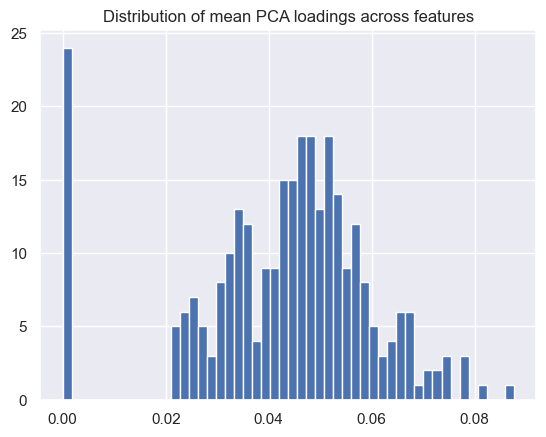

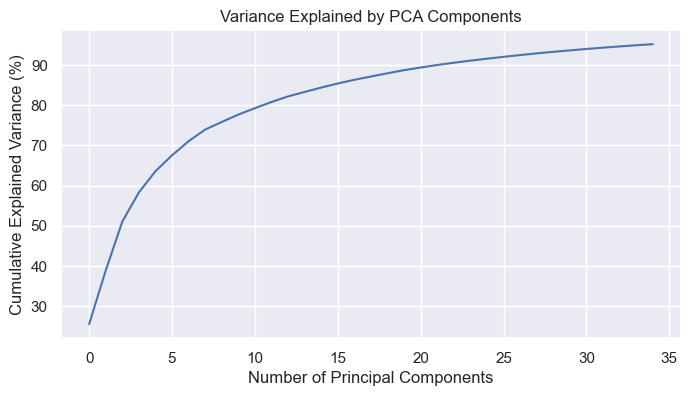

Samples: 90 | Original features: 292 | PCs kept: 35
Backhand: Best k=1, cov=diag, BIC=4373.12
Forehand: Best k=4, cov=diag, BIC=3683.63
Serves: Best k=2, cov=diag, BIC=4205.16


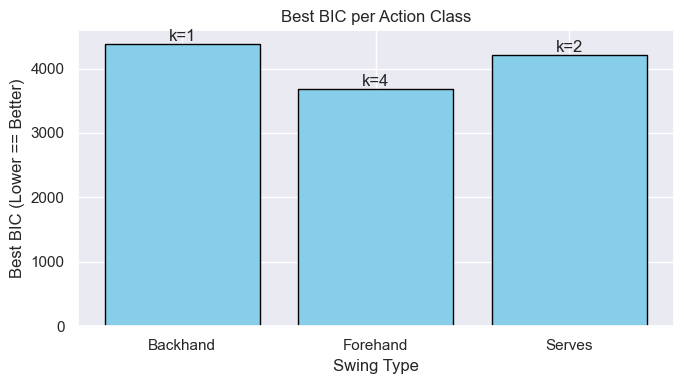

In [ ]:
''' 
    Links:
        mixture model : https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_selection.html
        v stack : https://www.geeksforgeeks.org/python/numpy-vstack-in-python/
        PCS variance : https://medium.com/@sahin.samia/principal-component-analysis-pca-made-easy-a-complete-hands-on-guide-e26a3680c0bc

'''

from collections import defaultdict


def fit_scaler(data:np.ndarray):
    # Sclaing data based on all of it
    scaler = StandardScaler().fit(data)
    return scaler


def build_expanded_feature_names(base_names:list):
    stats = ["mean", "var", "min", "max"]
    # Building 888 size column names to match X_data
    expanded = [f"{stat}_{name}" for stat in stats for name in base_names]
    return expanded


def calculate_action_summaries(feat_array:np.ndarray):
    ''' Calculate the mean, variance, min and max for all columns for each sample
    Args:
        feat_array (np.ndarray) : 1 repetition of an action
    Returns:
        means, vars, mins, maxs
    '''
    # Calculate  column stats
    means = feat_array.mean(axis=0)
    vars = feat_array.var(axis=0)
    mins  = feat_array.min(axis=0)
    maxs  = feat_array.max(axis=0)
    return np.concatenate([means, vars, mins, maxs])



def build_swing_action_dataset(train_data:dict):
    ''' Function to build the dataset that ill feed into the gmms
    Args:
        array_folder_path (String) : String file path to folder containing all json data
        swing_types (List) : List of actions
    '''
    X_train = []
    y_train = []
    swing_dict = {}
    print(train_data.keys())

    for swing_label, swing_data in train_data.items():
        summaries = []
        for ndarray in swing_data:
            # Loading pose array from JSON
            # feature_array = ast.literal_eval(array_str)
            ndarray = np.nan_to_num(ndarray)
            X = np.array(ndarray, dtype=np.float32)
            # Get overall statistics of movement
            s = calculate_action_summaries(X)
            summaries.append(s)

        summary_vert = np.vstack(summaries)
        swing_dict[swing_label] = summary_vert
        X_train.append(summary_vert)
        # extend labels with one label per clip in this class
        y_train.extend([swing_label] * summary_vert.shape[0])

    # Final stacks
    X_data = np.vstack(X_train)
    y_train = np.array(y_train) 

    return swing_dict, X_data, y_train


# def fit_GMM_to_actions(swing_dict: dict, scaler: StandardScaler, pca: PCA, n_components_options=[1, 2, 3, 4], cov_types=['diag', 'full'], reg_covar: float = 1e-3, random_state: int = 42):
def fit_GMM_to_actions(swing_dict:dict, scaler:StandardScaler, pca:PCA, n_components_options:list =[1, 2, 3, 4], cov_types:list =['diag'], reg_covar:float =1e-4, random_state:int =RANDOM_STATE):
    '''Fit one global StandardScaler and PCA, then a per-class Gaussian Mixture Model (GMM) with BIC-based model selection for each swing type.
    Args:
        swing_dict (dict): Dictionary where K == swing type & V == vertically stacked clip summaries
        scaler (StandardScaler): Fitted scaler used to normalize data 
        pca (PCA): Fitted PCA object for dimensionality reduction before fitting GMMs
        n_components_options (List): List of number of mixtures to try
        cov_types (List): Covariance types to try
        reg_covar (float): Regularization term added to the diagonal of covariance matrices to make it more stable
        random_state (int): Random seed
    Returns:
        scaler (StandardScaler): The same fitted scaler passed in
        mixtures_dict (dict): {swing_label: best_fitted_GaussianMixture}
        results_dict (dict): {swing_label: {"bic": best_bic, "k": n_components, "cov": covariance_type}}
    '''
    results_dict = {}
    mixtures_dict = {}

    # Iterate over each swing type (class)
    for swing_label, X_train in swing_dict.items():
        # Scale swing data to same scale as global dataset
        X_scaled = scaler.transform(X_train)
        # Apply PCA transformation for dimensionality reduction
        X_reduced = pca.transform(X_scaled)
        # Convert to float64 for numerical stability (GMMs prefer this)
        X_reduced = X_reduced.astype(np.float64)

        # Track all trials so we can plot BIC vs k later
        trial_k_list   = []
        trial_bic_list = []
        trial_cov_list = []
        best_model = None
        best_bic = np.inf  # initialize with infinity for comparison

        # Loop through all covariance types and number of components to find best model
        for cov_type in cov_types:
            for n_components in n_components_options:
                # Initialize and fit GMM for current config
                mixture_model = GaussianMixture(n_components=n_components, covariance_type=cov_type, reg_covar=reg_covar, init_params="kmeans", n_init=5, max_iter=500, random_state=random_state)
                mixture_model.fit(X_reduced)
                bic_value = mixture_model.bic(X_reduced)

                # Store all atytempts for plotting
                trial_k_list.append(n_components)
                trial_bic_list.append(float(bic_value))
                trial_cov_list.append(cov_type)

                # Update if this model has a lower BIC (better balance of fit vs complexity)
                if bic_value < best_bic:
                    best_model, best_bic = mixture_model, bic_value

        # Aggregate to best BIC per k (across covariance types) for a clean BIC-vs-k curve
        bic_per_k = defaultdict(list)
        for k, bic, cov in zip(trial_k_list, trial_bic_list, trial_cov_list):
            bic_per_k[k].append(bic)

        k_list   = sorted(bic_per_k.keys())
        bic_list = [min(bic_per_k[k]) for k in k_list]

        # Store best results for each model
        mixtures_dict[swing_label] = best_model
        results_dict[swing_label] = {
            "bic": float(best_bic),
            "k": int(best_model.n_components),
            "cov": best_model.covariance_type,
            "reg_covar": reg_covar,
            "k_list": k_list,
            "bic_list": bic_list,
            "trial_k_list": trial_k_list,
            "trial_bic_list": trial_bic_list,
            "trial_cov_list": trial_cov_list
        }

        print(f'{swing_label}: Best k={best_model.n_components}, cov={best_model.covariance_type}, BIC={best_bic:.2f}')
    return scaler, mixtures_dict, results_dict



def display_most_influential_features(components, col_list:list, show_dist:bool =False):
    ''' 
    '''
    # Magnitudes of contribution to variance
    abs_mags = np.abs(components)
    # Average loading across all components 
    mean_loading = abs_mags.mean(axis=0)
    # Rank features by importance
    top_features_idx = np.argsort(mean_loading)[::-1]  # descending
    top_features = [(col_list[i], mean_loading[i]) for i in top_features_idx[:20]]
    df = pd.DataFrame(top_features, columns=["feature", "mean_abs_loading"])
    # Normalise importance
    df["relative_importance"] = df["mean_abs_loading"] / df["mean_abs_loading"].max()

    if show_dist:
        print(df)
        plt.hist(mean_loading, bins=50)
        plt.title("Distribution of mean PCA loadings across features")
        plt.show()
    return df

    


def PCA_feature_analysis(X_data: np.ndarray, scaler:StandardScaler, col_list:list, variance_percentile:float =0.95, top_n:int =50, show_important_features:bool =True, show_var_ratio:bool =False):
    ''' Function for component analysis and to see how useful each feature actually is 
    Args:
        x_data (ndarray) : All X data
        scaler (StandardScaler) : scaler for x_data
        top_n (Int) : The top N features that we want to keep
        show_var_ratio (Bool) : Plot variance ratio or not
    '''
    X_scaled = scaler.transform(X_data)

    if variance_percentile:
        pca = PCA(n_components=variance_percentile, random_state=RANDOM_STATE)
        X_reduced = pca.fit_transform(X_scaled)
        kept = pca.n_components_
        if show_important_features:
            pca_df = display_most_influential_features(pca.components_, col_list, show_dist=True)
    else:
        pca = PCA(n_components=top_n, random_state=RANDOM_STATE)
        X_reduced = pca.fit_transform(X_scaled)
        kept = top_n
        if show_important_features:
            pca_df = display_most_influential_features(pca.components_, col_list, show_dist=True)

    # Plot variance ratio
    if show_var_ratio:
        plt.figure(figsize=(8,4))
        plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100)
        plt.xlabel('Number of Principal Components')
        plt.ylabel('Cumulative Explained Variance (%)')
        plt.title('Variance Explained by PCA Components')
        plt.grid(True)
        plt.show()
        plt.close()

    n_samples, n_feat = X_data.shape
    print(f'Samples: {n_samples} | Original features: {n_feat} | PCs kept: {kept}')
    return scaler, pca, X_reduced, pca_df


def gaussian_mixture_main(feature_names:list, train_files_dict:dict):
    ''' Main functrion for building gaussian mixture models that will be used as a baseline for comparison against my other models
    '''
    # Only train using the swing actions
    train_data = {k : v for k, v in train_files_dict.items() if k != 'NoStroke'}
    # Build action dataset from saved numpy array objects
    swing_dict, X_data, y_data = build_swing_action_dataset(train_data)
    # Get inflated list of column names o keep in line with calculate_action_summaries()
    expanded_col_list = build_expanded_feature_names(feature_names)
    # calculate scaler for data
    scaler = fit_scaler(X_data)
    # Remove useless features
    scaler, pca, X_reduced, pca_df = PCA_feature_analysis(X_data, scaler, expanded_col_list, variance_percentile=0.95, show_var_ratio=True)
    # Find best mixture model to suit each swing type 
    scaler,  mixtures_dict, results_dict = fit_GMM_to_actions(swing_dict, scaler, pca, random_state=RANDOM_STATE)
    
    # Plot BIC differences between mixtures
    gp = GraphPlotter('')
    gp.plot_BIC_hist(results_dict)
    # Save scale, pca, models from trianing in pickle
    create_folder('data/models/')
    dump({
        'scaler': scaler,
        "pca": pca,
        'mixtures' : mixtures_dict,
        'feature_names' : pca_df.columns,
        'results_dict' : results_dict,
        'pca_df' : pca_df,
    }, "data/models/tennis_mixture_models.pkl")
    
    return mixtures_dict, results_dict, scaler
        

# mixtures_dict, results_dict = gaussian_mixture_main(col_list, train_file_path='data/json_data/numpy_feature_arrays/train_files.json')
mixtures_dict, results_dict, scaler = gaussian_mixture_main(col_list, train_files_dict)


## Plan

* compute all my feattures
* Split dataset into train / val /test 
* Do PCA same as Gaussian notebook
* Fit scaler on train for GMM
* train GMM on train only (Results might be worse since now have to create val set as well as test for less samples to train on)
* train GMM on swings only or still include noStroke incase LSTM gets it wrong?
* Train LSTM on train and val like before 


links:
* np.savez_compressed : https://numpy.org/doc/2.2/reference/generated/numpy.savez_compressed.html
* g4g LSTM : https://www.geeksforgeeks.org/deep-learning/deep-learning-introduction-to-long-short-term-memory/
* LSTM docs : https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html
* MLMastery Multi LSTM : https://machinelearningmastery.com/multivariate-time-series-forecasting-lstms-keras/

* Sequence length : https://stackoverflow.com/questions/49573242/what-is-sequence-length-in-lstm
* Sequence length for action recognition : https://www.sciencedirect.com/science/article/pii/S2468227623002521


Plan:
* Start by taking the whole 2 second clips as our sequence length as baseline
    * use dataset as i got it 
* Split NoStroke into 'other movement' and 'idle / ready position' class and retrain

Need to differenciat between 'other Movement' class and idel / ready position class


NoStroke files that contains stratof swing:
* NS_25
* NS_26
* NS_30
* NS_31
* NS_32
* NS_33
* NS_35
* NS_36
* NS_38 (Start of serve but might be ok)?


Idle files:
* NS_20
* NS_27
* NS_28
* NS_29
* NS_37
* NS_39
* NS_40

In [ ]:
def flatten_data_dict(data_dict: dict):
    X_data, y_data = [], []
    for swing_type, samples in data_dict.items():
        X_data.extend(samples)                       # list of (Ti, F) arrays
        y_data.extend([swing_type] * len(samples))
    return X_data, y_data

def encode_binary_labels(y_list):
    # Example: {"NoStroke": 0, "Forehand": 1, "Backhand": 1, "Serve": 1}
    return np.array([BINARY_SWING_DICT[y] for y in y_list], dtype=np.int64)

def fit_seq_scaler_on_train(train_seq_list):
    # Concatenate real timesteps only (no padding)
    feat_dim = train_seq_list[0].shape[1]
    scaler = StandardScaler()
    concat = np.vstack(train_seq_list)              # (sum(Ti), F)
    scaler.fit(concat)
    return scaler

def transform_seq_list(seq_list, scaler):
    # Apply per-timestep normalization to each sequence
    return [scaler.transform(x).astype(np.float32) for x in seq_list]

def pad_sequences(seq_list, window_len, crop="head"):
    """
    Pads (or crops) to (N, window_len, F). Returns lengths as well.
    crop: 'head' keeps the first window_len frames,
          'tail' keeps the last window_len frames,
          'center' center-crop.
    """
    N = len(seq_list)
    F = seq_list[0].shape[1]
    X = np.zeros((N, window_len, F), dtype=np.float32)
    lengths = np.zeros((N,), dtype=np.int64)
    for i, s in enumerate(seq_list):
        T = s.shape[0]
        if T <= window_len:
            X[i, :T] = s
            lengths[i] = T
        else:
            if crop == "head":
                X[i] = s[:window_len]
            elif crop == "tail":
                X[i] = s[-window_len:]
            else:  # center
                start = (T - window_len) // 2
                X[i] = s[start:start+window_len]
            lengths[i] = window_len
    return X, lengths

def load_LSTM_data_main(train_files_dict, val_files_dict, test_files_dict, window_len=60):
    # 1) Flatten
    X_train_list, y_train_str = flatten_data_dict(train_files_dict)
    X_val_list,   y_val_str   = flatten_data_dict(val_files_dict)
    X_test_list,  y_test_str  = flatten_data_dict(test_files_dict)

    # 2) Labels (sequence-level; no padding)
    y_train_int = encode_binary_labels(y_train_str)
    y_val_int   = encode_binary_labels(y_val_str)
    y_test_int  = encode_binary_labels(y_test_str)

    # 3) Fit scaler on TRAIN (un-padded), then transform all splits
    seq_scaler     = fit_seq_scaler_on_train(X_train_list)
    X_train_scaled = transform_seq_list(X_train_list, seq_scaler)
    X_val_scaled   = transform_seq_list(X_val_list,   seq_scaler)
    X_test_scaled  = transform_seq_list(X_test_list,  seq_scaler)

    # 4) Pad after scaling (and keep lengths for masking/packing)
    X_train, len_train = pad_sequences(X_train_scaled, window_len)
    X_val,   len_val   = pad_sequences(X_val_scaled,   window_len)
    X_test,  len_test  = pad_sequences(X_test_scaled,  window_len)

    return (X_train, y_train_int, len_train,
            X_val,   y_val_int,   len_val,
            X_test,  y_test_int,  len_test,
            seq_scaler, y_train_str, y_val_str, y_test_str)

LSTM_dataset = load_LSTM_data_main(train_files_dict, val_files_dict, test_files_dict, window_len=60)
X_train_LSTM, X_val_LSTM, X_test_LSTM, y_train_int, 
y_train_int, len_train, y_val_int, len_val,  y_test_int,  len_test, seq_scaler, y_train_str, y_val_str, y_test_str = LSTM_dataset


In [ ]:
# def load_swing_data(npz_folder_path:str):
#     ''' Load all saved npz files into X_train and y_train
#     Args:
#         npz_folder_path (String) : Folder path to fodler containing all swing .npz files
#     Returns:
#         X_train (List) : 
#         y_train (List) : 
#     '''
#     X_train = []
#     y_train = []
#     file_names = []
#     for file_name in os.listdir(npz_folder_path):
#         class_name = file_name.split(".")[0]
#         swing_data = np.load(f'{npz_folder_path}{file_name}', allow_pickle=True)
#         action_dict = swing_data['swings']
#         uids = swing_data['uid']
#         for i in range(0, len(action_dict)):
#             X_train.append(action_dict[i])
#             y_train.append(class_name)
#             file_names.append(uids[i])

#     return X_train, y_train, file_names



# def data_preprocessing(X_train:list, y_train:list, window_len:int, show:bool =False):
#     ''' 
#     Links:
#         count number of occurances of value in np array : https://stackoverflow.com/questions/42751662/numpy-ndarray-object-has-no-attribute-count
#     '''
#     # Load X_train into one array and pad samples smaller than window_len
#     X_padded = np.zeros((len(X_train), window_len, X_train[0].shape[1]), dtype=np.float32)
#     for index, sample in enumerate(X_train):
#         t = min(window_len, sample.shape[0])
#         X_padded[index, :t] = sample[:t]

#     # NOTE - Change here form LSTM_model.ipynb so that all swings saved as the same action vs no swing
#     # Encode class names to ints from file names for crossentropyloss
#     # class_dict = {swing_name : index for index ,swing_name in enumerate(SWING_TYPES)}
#     y_int_classes = np.array([BINARY_SWING_DICT[swing_type] for swing_type in y_train], dtype=np.int64)
#     if show:
#         pretty_print_json(BINARY_SWING_DICT)
#         print('Y Classes as Int:', y_int_classes)
#         print('Len Dataset:', len(y_int_classes))
#         print('Class counts:')
#         print('Swings:', np.count_nonzero(y_int_classes == 0))
#         print('Not a swing:', np.count_nonzero(y_int_classes == 1))

#     return X_padded, y_int_classes



# def scale_datasets(X_train, X_val):
#     ''' Scale dataset values to same size so acceleeration/velocity doesnt amplify noise
#     Args:
#     '''
#     n_samps_train, n_frames, n_feats = X_train.shape
#     n_samps_val = X_val.shape[0]
#     scaler = StandardScaler()
#     X_train = scaler.fit_transform(X_train.reshape(-1, n_feats)).reshape(n_samps_train, n_frames, n_feats).astype(np.float32)
#     X_val = scaler.transform(X_val.reshape(-1, n_feats)).reshape(n_samps_val, n_frames, n_feats).astype(np.float32)
#     return X_train, X_val, scaler




# def flatten_data_dict(data_dict:dict):
#     '''  Convert each trand & val X_data from {'swing_type' : [ [ndarray1], [ndarray2]]} --> 1D list of arrays
#     '''
#     X_data = []
#     y_data = []
#     for swing_type, swing_array in data_dict.items():
#         X_data += swing_array
#         y_data += [swing_type] * len(swing_array)
#     return X_data, y_data



# def load_LSTM_data_main(train_files_dict:dict, val_files_dict:dict, test_files_dict:dict, window_len:int =60):
#     ''' 
#     Args:
#         npz_folder_path (String) : Folder path to folder containinng .npz files for all 
#         window_len
#     '''
#     # Load saved .npz swing data
#     # X_data, y_data, file_names = load_swing_data(npz_folder_path)
#     X_train, y_train_str = flatten_data_dict(train_files_dict)
#     X_val, y_val_str = flatten_data_dict(val_files_dict)
#     X_test, y_test_str = flatten_data_dict(test_files_dict)


#     # Scale dataset to deal with velocity and FPS values
#     # NOTE Need to remove either delta or Velo becuase theyre colinear
#     X_train, X_val, scaler = scale_datasets(X_train, X_val)

#     # Pad samples so theyre all the same length
#     X_train_padded, y_train_int_LSTM = data_preprocessing(X_train, y_train_str, window_len, show=False)
#     X_val_padded, y_val_int_LSTM = data_preprocessing(X_val, y_val_str, window_len, show=False)
#     X_test_padded, y_test_int_LSTM = data_preprocessing(X_test, y_test_str, window_len, show=False)

#     return X_train_padded, X_val_padded, X_test_padded, y_train_int_LSTM, y_val_int_LSTM, y_test_int_LSTM, y_train_str, y_val_str, y_test_str
#     # return X_train, X_val, X_test, y_train, y_val, y_test, y_train_int_LSTM, y_val_int_LSTM, scaler




# # NOTE - Updated preprocessing to scale the Train & val split ive made above and to return the list of classes as strings of action type as well as binary swing / not swing
# window_len = 60
# npz_all_folder_path = 'data/json_data/npz/all/'
# X_train_LSTM, X_val_LSTM, X_test_LSTM, y_train_int_LSTM, y_val_int_LSTM, y_test_int_LSTM, y_train_str, y_val_str, y_test_str = load_LSTM_data_main(train_files_dict, val_files_dict, test_files_dict, window_len=window_len)

AttributeError: 'list' object has no attribute 'shape'

## Training pipeline

In this section is where ill define:
* A simple data loader pipeline for the dataset to take the splitt dataset from above cell
* My LSTM model Acrhitecture
* My training pipeline

In [ ]:
class SwingDataset(Dataset):
    def __init__(self, X_list, y_ids, dtype=torch.float32):
        self.X = X_list
        self.y = y_ids
        self.dtype = dtype

    def __len__(self): 
        return len(self.X)
    
    
    def __getitem__(self, i):
        x = self.X[i]
        if not torch.is_tensor(x):
            x = torch.as_tensor(x, dtype=self.dtype)
        else:
            x = x.to(self.dtype)
        y = int(self.y[i])
        return x, y


def load_dataset(X_train, X_valid, X_test, y_train, y_valid, y_test, batch_size=16):
    ''' 
    Args:
        X_train (List) : 
        X_valid (List) :
        X_test (List) :
        y_train (List) :
        y_valid (List) :
        y_test (List) :
        batch_size (List) :
    Returns:
        train_dataset, val_dataset, train_loader, val_loader
    '''
    # Create dataset
    train_dataset = SwingDataset(X_train, y_train)
    val_dataset   = SwingDataset(X_valid, y_valid)
    test_dataset   = SwingDataset(X_test, y_test)

    # Create DataLoaders
    num_workers = min(8, os.cpu_count() // 2)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False, persistent_workers=False)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False, persistent_workers=False)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False, persistent_workers=False)
    return train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader

# X_train_LSTM, X_valid_LSTM, X_test_LSTM, y_train_LSTM, y_valid_LSTM, y_test_LSTM, y_train_int_classes, y_val_int_classes, LSTM_scaler
# Load datasets
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = load_dataset(X_train_LSTM, X_valid_LSTM, X_test_LSTM, y_train_int_LSTM, y_valid_LSTM, y_val_int_LSTM)

LSTM Architecture

In [77]:
'''
Links:
    bidirectional LSTM : https://medium.com/@anishnama20/understanding-bidirectional-lstm-for-sequential-data-processing-b83d6283befc

'''
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden=128, num_classes=4, dropout=0.3, bidirectional=True):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden, batch_first=True, bidirectional=bidirectional)
        # Change output dimensions if we're loking forward & backward
        out_dim = hidden
        if bidirectional:
            out_dim = hidden * 2
        
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(out_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # get hidden states
        _, (h_n, _) = self.lstm(x)
        
        # If bidirect I combine the last forward and backward states
        if self.lstm.bidirectional:
            forward_h  = h_n[-2]
            backward_h = h_n[-1]
            h = torch.cat((forward_h, backward_h), dim=1)
        # Or just take last layer
        else:
            h = h_n[-1]

        out = self.head(h)
        return out

## Training loop

In [27]:
import copy
import sklearn.metrics

def train_model(model, 
                epochs: int, 
                device, 
                train_loader, 
                val_loader, 
                train_size, 
                val_size, 
                batch_size:int =64,
                lr: float =0.003, 
                weight_decay: float =0.0001, 
                patience: int =5, 
                min_delta: float =1e-3,
                save_best: bool =False,
                best_save_dir:str = None):
    ''' Training loop
    Args:
        model (Object) : Model architecture being trained
        epochs (Int) : Num epochs to train for 
        device_type (String) : Device being trained on either 'cuda' or 'cpu'
        batch_size (Int) : Num samples per batch
        lr (Float) : Learning rate 
        weight_decay (Float) : Float udner for regularisation
        patience (Int) : Num epochs we weait for improvment before stopping
        min_delta=1e-4 (Float) : Minimum improvement needed for patience to be reset
    Returns:
        model (Model) : Trained model
        training_history (Dict) : Dict where K == metric && V == List containing metrics value over training epochs
    '''
    # Define the loss function, optimizer & scheduler to decrease leanring rate
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05) # label_smoothing to try reduce variance in my validation loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)
    
    # Training stats collection
    training_history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [],  "val_acc": [],
        "train_f1": [],   "val_f1": []
    }
    # Earlly stopping variables
    best_val_loss = float("inf")
    epochs_without_improve = 0
    # store best version copy to save best performing weights in case it gets worse while waiting for patience to expire
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        print(f'Epoch: {epoch + 1}/{epochs}')
        model.train()
        # Initialize the training loss and accuracy for this epoch
        train_preds = []
        full_y_train = []
        running_val_loss = 0.0
        running_train_loss = 0.0
        running_val_corrects = 0
        running_train_corrects = 0
        
        for i, (X_train, y_train) in tqdm(enumerate(train_loader), desc=f'Epoch: {epoch}'):
            # Move data to gpu
            X_train = X_train.to(device, non_blocking=True)
            y_train = y_train.to(device, non_blocking=True)
            
            # Calculate loss
            optimizer.zero_grad()
            outputs = model(X_train)
            loss = criterion(outputs, y_train)
            loss.backward()
            
            # Added to stop gradients exploding in deeper 5 layer cnn
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            # Compute statistics
            running_train_loss += loss.item() * X_train.size(0)
            running_train_corrects += torch.sum(torch.argmax(outputs, dim=1) == y_train)
            
            t_preds = torch.argmax(outputs, dim=1)
            train_preds.extend(t_preds.detach().cpu().tolist())
            full_y_train.extend(y_train.detach().cpu().tolist())
        
        # Compute statistics for the entire epoch
        epoch_train_loss = running_train_loss / train_size
        epoch_train_acc = running_train_corrects.item() / train_size * 100
        epoch_train_f1_macro = sklearn.metrics.f1_score(full_y_train, train_preds, average = 'macro')
        
        # Save history stats
        training_history["train_loss"].append(epoch_train_loss)
        training_history["train_acc"].append(epoch_train_acc)
        training_history["train_f1"].append(epoch_train_f1_macro)


        # Evaluation on validation set
        val_preds = []
        full_y_val = []
        model.eval()
        with torch.no_grad():
            for X_val, y_val in val_loader:
                # Move to gpu 
                X_val = X_val.to(device, non_blocking=True)
                y_val = y_val.to(device, non_blocking=True)
                
                # Calculate val loss
                val_outputs = model(X_val)
                val_loss = criterion(val_outputs, y_val)
                v_preds = torch.argmax(val_outputs, dim=1)
                val_preds.extend(v_preds.detach().cpu().tolist())
                full_y_val.extend(y_val.detach().cpu().tolist())

                # Compute statistics
                running_val_loss += val_loss.item() * X_val.size(0)
                running_val_corrects += torch.sum(torch.argmax(val_outputs, dim=1) == y_val)

        # Compute statistics for the entire epoch
        epoch_val_loss = running_val_loss / val_size
        epoch_val_acc = running_val_corrects.item() / val_size * 100
        epoch_val_f1_macro = sklearn.metrics.f1_score(full_y_val, val_preds, average='macro')
        # Reduce lr
        scheduler.step(epoch_val_loss)

        # Store history
        training_history["val_loss"].append(epoch_val_loss)
        training_history["val_acc"].append(epoch_val_acc)
        training_history["val_f1"].append(epoch_val_f1_macro)
    
        print(f'Epoch {epoch+1}/{epochs} \n   Training Loss: {epoch_train_loss:.4f}, Training Accuracy: {epoch_train_acc:.2f}%, Training F1 Macro: {epoch_train_f1_macro:.2f}% \
            \n   Validation Loss: {epoch_val_loss:.4f}, Validation Accuracy: {epoch_val_acc:.2f}%, Validation F1 Macro: {epoch_val_f1_macro:.2f}%' )
        

        # Patience tracking before stopping
        # NOTE ToDo: Also need to add early stopping to avoid overfitting 
        if epoch_val_loss < best_val_loss - min_delta:
            prev_best = best_val_loss
            best_val_loss = epoch_val_loss
            epochs_without_improve = 0
            best_state = copy.deepcopy(model.state_dict())
            if save_best:
                torch.save({
                        "epoch": epoch + 1,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "scheduler_state_dict": scheduler.state_dict(),
                        "best_val_loss": best_val_loss,
                    },
                    best_save_dir,
                )
            print(f"Improved from {prev_best:.5f} --> {best_val_loss:.5f}. Resetting patience")
        else:
            epochs_without_improve += 1
            print(f"No improvement ({epochs_without_improve}/{patience}).")

            if epochs_without_improve >= patience:
                print(f"Early stopping triggered (patience={patience}).")
                break
    
    # Loading the best states weights 
    model.load_state_dict(best_state)
    return model, training_history

Iterate over choice of having bidirectional = True or False and comapre model results

In [ ]:
''' 
Links:
    Best eval metrics for LSTM : https://codesignal.com/learn/courses/time-series-forecasting-with-lstms/lessons/evaluating-and-visualizing-lstm-model-performance
    LSTM example : https://machinelearningmastery.com/multivariate-time-series-forecasting-lstms-keras/
'''

def test_loading_one_epoch(model, loader, device):
    x0, y0 = train_dataset[0]
    print("x0", type(x0), x0.shape, x0.dtype, "y0", y0, type(y0))
    assert x0.dtype == torch.float32 and x0.ndim == 2  # (T, F)
    assert isinstance(y0, int)
    # first batch
    xb, yb = next(iter(DataLoader(train_dataset, batch_size=8, num_workers=0)))
    print("batch", xb.shape, xb.dtype, yb.shape, yb.dtype)  # expect (B, T, F), float32; (B,), int64

    model.eval()
    it = iter(loader)
    import time, torch
    t0 = time.perf_counter()
    X, y = next(it)                   # data fetch
    t1 = time.perf_counter()
    X = X.to(device, non_blocking=True); y = y.to(device, non_blocking=True)
    torch.cuda.synchronize() if device.type == "cuda" else None
    t2 = time.perf_counter()
    with torch.no_grad():
        out = model(X)               # forward only
    torch.cuda.synchronize() if device.type == "cuda" else None
    t3 = time.perf_counter()
    print(f"fetch: {(t1-t0)*1000:.1f} ms | H2D: {(t2-t1)*1000:.1f} ms | fwd: {(t3-t2)*1000:.1f} ms | batch={X.size(0)}")



batch_size=16
train_size = len(train_dataset)
val_size = len(val_dataset)

bi_dict = {
    'LSTM-GMM_Bidirectional_True' : True,
    'LSTM-GMM_Bidirectional_False' : False
}

input_dims=F = X_train[0].shape[1]

create_folder('data/models/')
create_folder('data/json_data/training_history/')
for file_name, option in bi_dict.items():
    model = LSTMClassifier(input_dim=input_dims, bidirectional=option).to(device)

    # test_loading_one_epoch(model, train_loader, device)

    # Train model
    model, training_progression = train_model(model, 
                                                epochs=25, 
                                                device=device, 
                                                train_loader=train_loader, 
                                                val_loader=val_loader, 
                                                train_size=train_size, 
                                                val_size=val_size, 
                                                batch_size=batch_size,
                                                lr=1e-4, 
                                                weight_decay=1e-4, 
                                                min_delta=1e-3,
                                                patience=8, 
                                                save_best=False)
    
    save_JSON_object(f'data/json_data/training_history/{file_name}.json', training_progression)
    save_torch_model(model, save_folder='data/models/', file_name=file_name)
    del model


Epoch: 1/25


Epoch: 0: 9it [00:00, 29.93it/s]


Epoch 1/25 
   Training Loss: 1.3162, Training Accuracy: 60.00%, Training F1 Macro: 0.39%             
   Validation Loss: 1.2981, Validation Accuracy: 60.00%, Validation F1 Macro: 0.38%
Improved from inf --> 1.29812. Resetting patience
Epoch: 2/25


Epoch: 1: 9it [00:00, 207.94it/s]


Epoch 2/25 
   Training Loss: 1.2829, Training Accuracy: 62.14%, Training F1 Macro: 0.29%             
   Validation Loss: 1.2637, Validation Accuracy: 60.00%, Validation F1 Macro: 0.38%
Improved from 1.29812 --> 1.26375. Resetting patience
Epoch: 3/25


...

Epoch 23/25 
   Training Loss: 0.5055, Training Accuracy: 92.86%, Training F1 Macro: 0.92%             
   Validation Loss: 0.4809, Validation Accuracy: 93.33%, Validation F1 Macro: 0.93%
Improved from 0.53713 --> 0.48091. Resetting patience
Epoch: 24/25


Epoch: 23: 9it [00:00, 221.37it/s]


Epoch 24/25 
   Training Loss: 0.4494, Training Accuracy: 92.86%, Training F1 Macro: 0.92%             
   Validation Loss: 0.4140, Validation Accuracy: 93.33%, Validation F1 Macro: 0.93%
Improved from 0.48091 --> 0.41401. Resetting patience
Epoch: 25/25


Epoch: 24: 9it [00:00, 225.70it/s]

Epoch 25/25 
   Training Loss: 0.4503, Training Accuracy: 92.14%, Training F1 Macro: 0.91%             
   Validation Loss: 0.3521, Validation Accuracy: 96.67%, Validation F1 Macro: 0.96%
Improved from 0.41401 --> 0.35214. Resetting patience


## In this section ill be analysing the training process for both models

In [29]:
# def plot_generalisation_gap(df, architecture:str, save_dir:str =None, show:bool =False):
#     ''' Will have to subset this 96 columns too much
#     Args:
#         df (pd.DataFrame) : Df to plot
#         architecture (String) : Architecture type
#         save_dir (String) : save directory default is none
#         show (Bool) : Show or not
#     '''
#     sns.barplot(data=df, x="experiment_name", y="generalisation_gap", palette="flare")
#     plt.title(f"Large Positive Generalisation Gap for {architecture}")
#     plt.xticks(rotation=45, ha='right', fontsize=7)

#     plt.grid(True, linestyle="--", alpha=0.6)
#     if save_dir:
#         graph_save_path = f'{save_dir}generalisation_gap.png'
#         # print('graph_save_path:', graph_save_path)
#         plt.savefig(graph_save_path, dpi=300, bbox_inches='tight')
#     if show:
#         plt.show()
#     plt.close()


def plot_train_val_comparison(training_dict, train_key, val_key, title, y_label,save_dir=None, show=False):
    ''' Generic plotting function to plot train VS validation results
    Args:
        model_name (String) : Name of model who's features are being plotted
        training_dict (Dict) : Dict with K == features name && V == their progression over epochs
        train_key (String) : Key for train measure to plot
        val_key (String) : Key for validation measure to plot
        title (String) : Title
        y_label (String) : Y-Axis label
        save_dir (String) : Save directory path, default is none
        show (Bool) : Plot graph or not
    '''
    plt.figure(figsize=(10, 6))
    plt.plot(training_dict[train_key])
    plt.plot(training_dict[val_key])
    plt.title(title)
    plt.ylabel(y_label)
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper right')
    plt.grid(True, linestyle="--", alpha=0.6)
    
    if save_dir:
        plt.savefig(f'{save_dir}{title}.png', dpi=300, bbox_inches='tight')
    if show:
        plt.show()
    plt.close()



def plot_feature_across_trainings(model_performance_dict: dict, feature_name: str=None, y_label: str=None, save_dir=None, show=False, plot_val=True):
    ''' Function to plot training performance of a specific feature across mutliple training of models with different model architectures
    Args:
        model_performance_dict (Object) : Dict object holding all training data for all models
        feature_name (String) : Key name of feature we want to plot for all models
        varied (String) : Training variable from setup that vary
        varied (String) : Training variable from setup that are fixed
        save_dir (String) : Save directory path, default is none
        show (Bool) : Plot graph or not
    '''
    plt.figure(figsize=(10, 6))
    model_names = []
    for model_name, train_dict in model_performance_dict.items():
        plt.plot(train_dict[feature_name], label=model_name)
        model_names.append(model_name)

    title = f"{feature_name.capitalize()} comparison for {' vs '.join(model_names)}"
    print(title)
    # Graph setup
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(feature_name)
    plt.legend(title="Models")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    if save_dir:
        graph_save_path = f'{save_dir}{feature_name}.png'
        plt.savefig(f'{save_dir}{feature_name}.png', dpi=300, bbox_inches='tight')
    if show:
        plt.show()
    plt.close()



def create_summay_df(training_histories_path):
    ''' creates a DF of the last value in each training metric for all queried models
    Args:
        training_histories_path (String) : String file path to folder
    Returns:
        summary_df (pd.DataFrame) : Summary DF of all trainin histories
    '''
    final_metrics = []
    for file_name in os.listdir(training_histories_path):
        training_data = load_JSON_object(f'data/json_data/training_history/{file_name}')
        final_metrics.append({
            "model": file_name.replace('.json', ''),
            "final_train_acc": training_data["train_acc"][-1],
            "final_val_acc": training_data["val_acc"][-1],
            "final_val_loss": training_data["val_loss"][-1],
            "final_val_f1": training_data["val_f1"][-1],
        })
    summary_df = pd.DataFrame(final_metrics)
    summary_df["generalisation_gap"] = summary_df["final_train_acc"] - summary_df["final_val_acc"]
    return summary_df



def compare_specific_models(model_list:list, training_history_folder_path:str, plot_output_folder:str):
    ''' Compare these tow if i need to
    Args:
        model_list
        training_history_folder_path
    '''
    # Load all training history data
    training_data = {model_name : load_JSON_object(f'{training_history_folder_path}{model_name}.json') for model_name in model_list}
    # print(training_data)
    plot_feature_across_trainings(training_data, feature_name='train_loss', y_label='Loss', save_dir=f'{plot_output_folder}model_comparison/', show=True, plot_val=True)
    plot_feature_across_trainings(training_data, feature_name='train_acc', y_label='Accuracy', save_dir=f'{plot_output_folder}model_comparison/', show=True, plot_val=True)
    plot_feature_across_trainings(training_data, feature_name='train_f1', y_label='train_f1', save_dir=f'{plot_output_folder}model_comparison/', show=True, plot_val=True)

    # Plotr training progression for all graphs
    for model_name, training_history in training_data.items():
        create_folder(f'{plot_output_folder}{model_name}/')
        # Plot accuracy
        plot_train_val_comparison(training_history, train_key='train_acc', val_key='val_acc', title=f'{model_name.replace("_", " = ")} Accuracy', y_label='Accuracy', save_dir=f'{plot_output_folder}{model_name}/', show=True)
        # plot loss
        plot_train_val_comparison(training_history, train_key='train_loss', val_key='val_loss', title=f'{model_name.replace("_", " = ")} Loss', y_label='Loss', save_dir=f'{plot_output_folder}{model_name}/', show=True)
        # plot f1 macro
        plot_train_val_comparison(training_history, train_key='train_f1', val_key='val_f1', title=f'{model_name.replace("_", " = ")} F1 Macro', y_label='F1 Macro', save_dir=f'{plot_output_folder}{model_name}/', show=True)


In this cell ill call all of the plotting functionality above

Train_loss comparison for LSTM-GMM_Bidirectional_True vs LSTM-GMM_Bidirectional_False


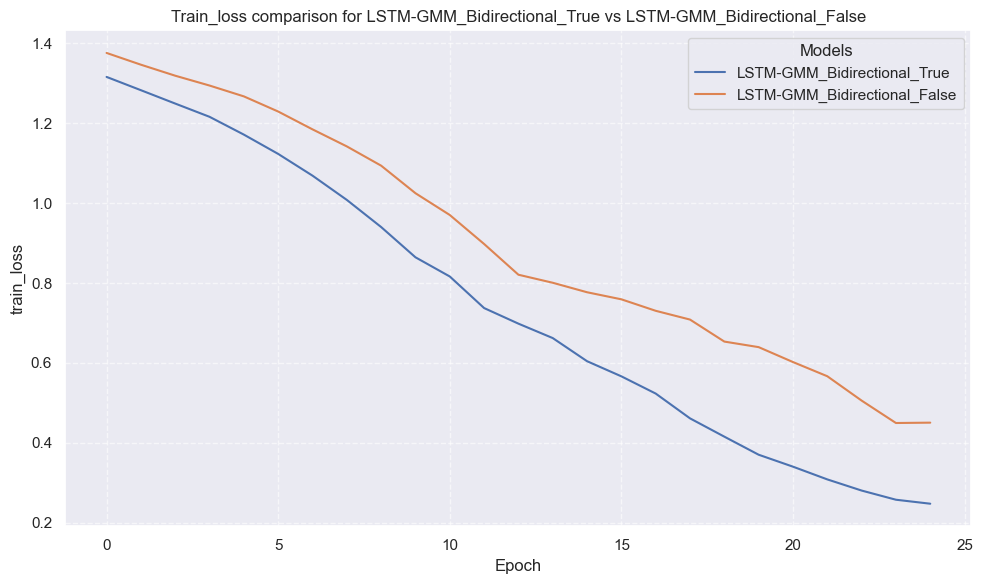

Train_acc comparison for LSTM-GMM_Bidirectional_True vs LSTM-GMM_Bidirectional_False


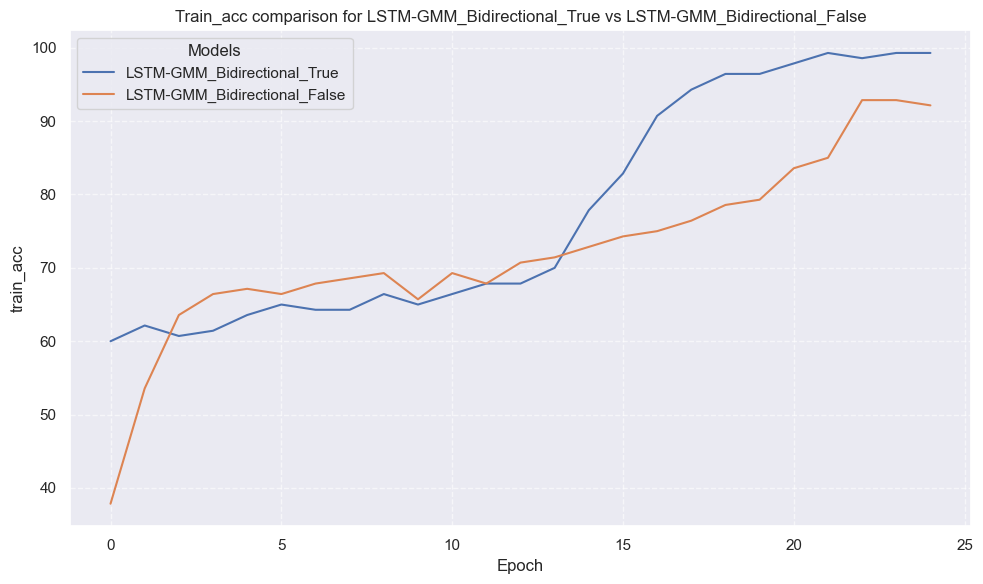

Train_f1 comparison for LSTM-GMM_Bidirectional_True vs LSTM-GMM_Bidirectional_False


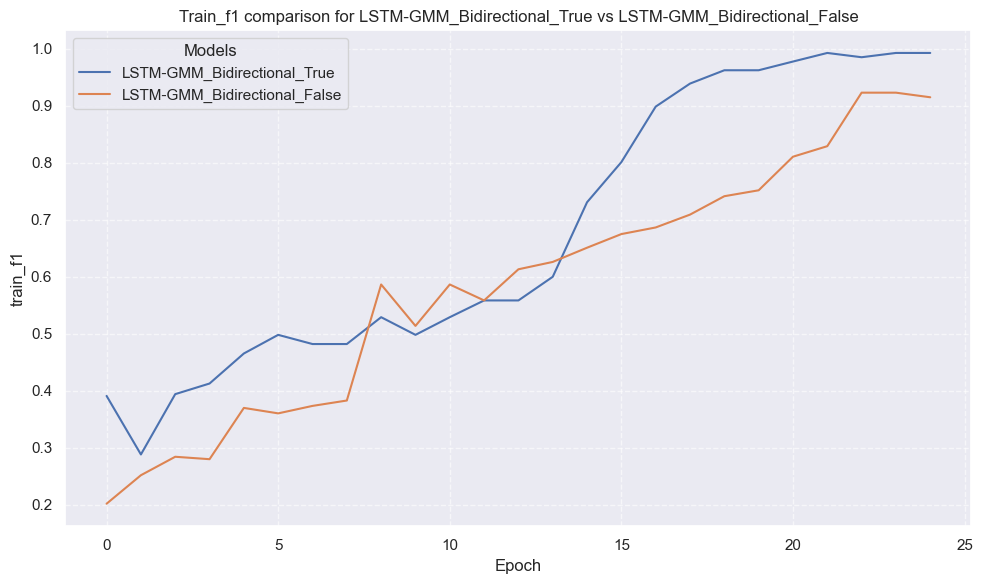

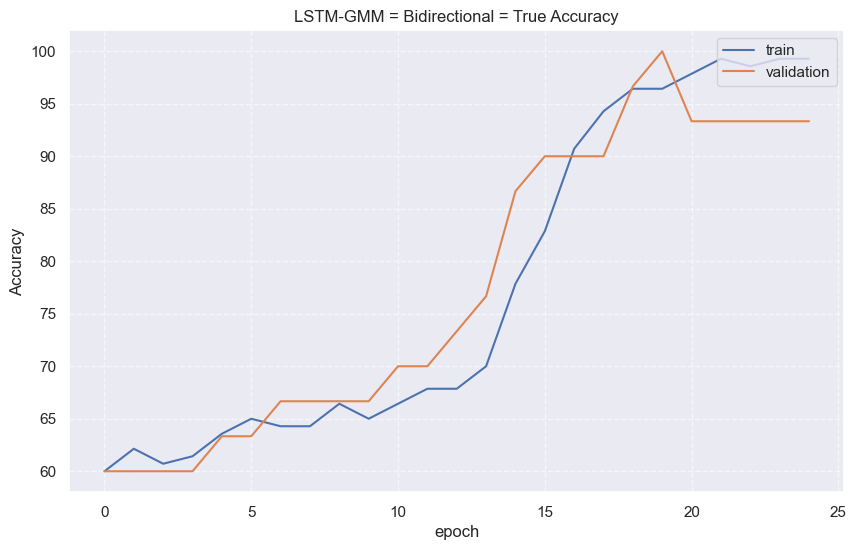

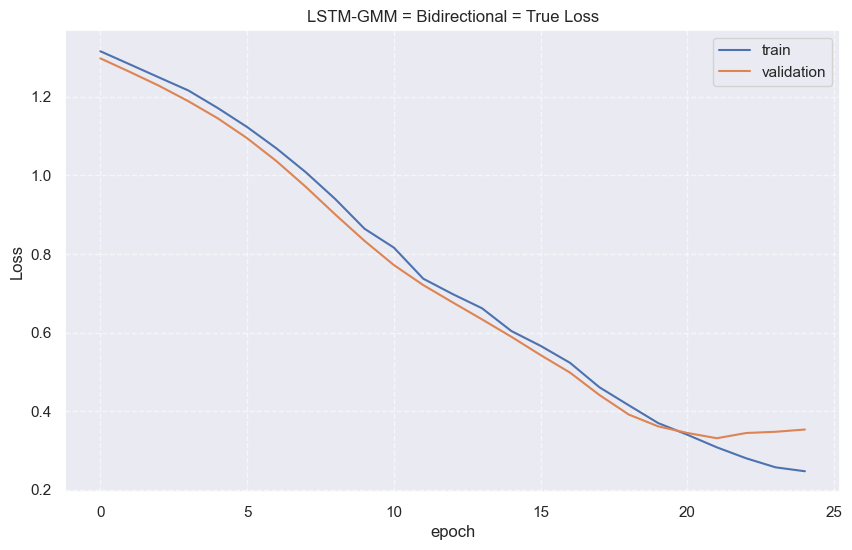

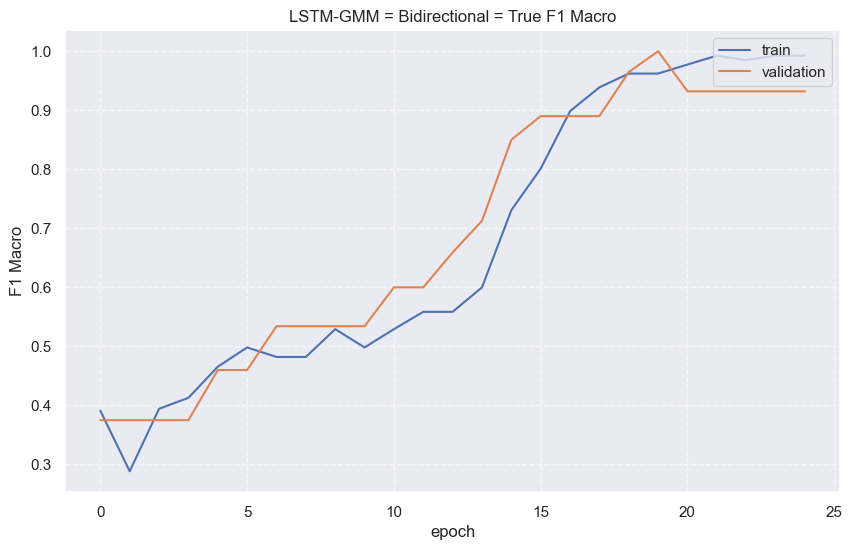

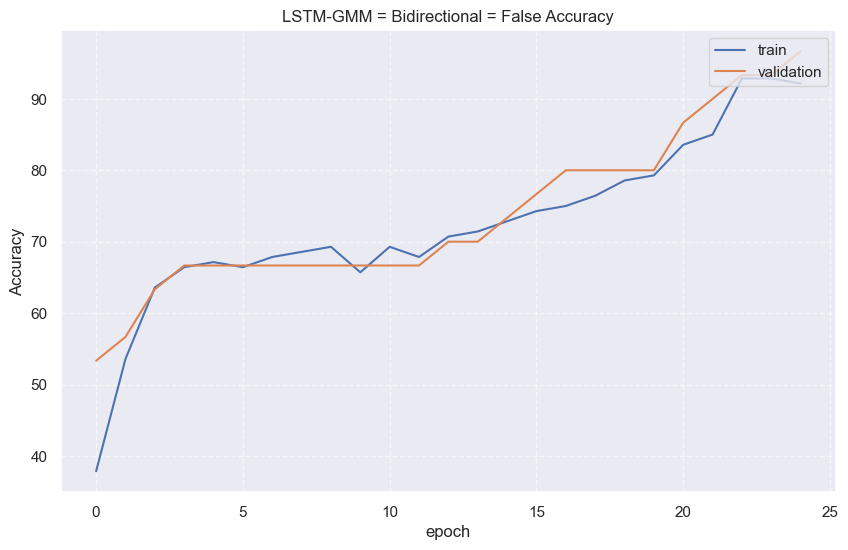

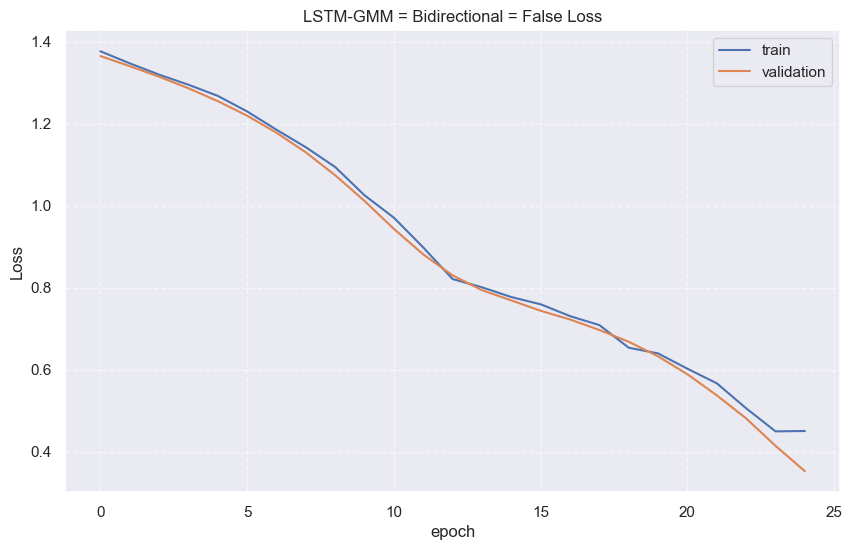

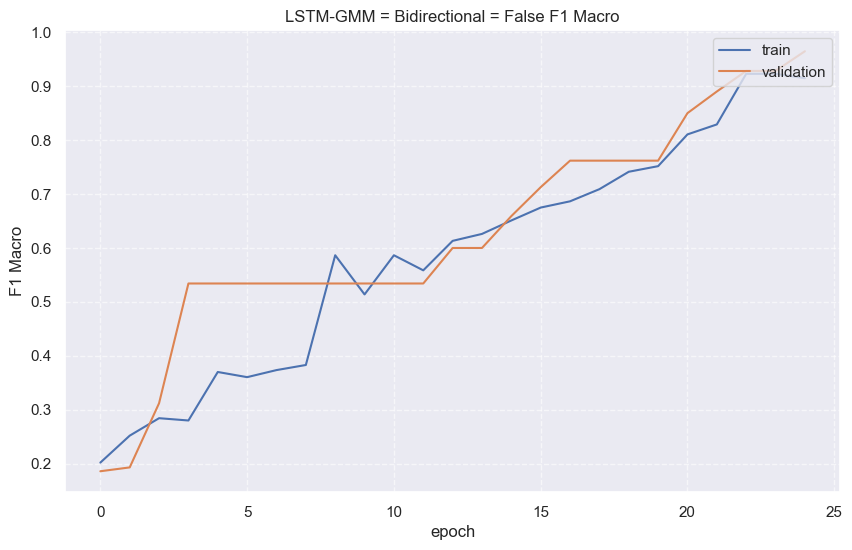

In [30]:
# 'swing_vs_not_swing_Bidirectional_True' : True,
#     'swing_vs_not_swing_Bidirectional_False' : False

# Models to compare
specific_models = ['LSTM-GMM_Bidirectional_True', 'LSTM-GMM_Bidirectional_False']

plot_output_folder = 'data/graphs/'
comparison_folder = 'data/graphs/model_comparison/'
training_history_folder_path = 'data/json_data/training_history/'
create_folder('data/csv/')
create_folder(comparison_folder)
create_folder(plot_output_folder)

# Plot comparisons of training metrics
compare_specific_models(specific_models, training_history_folder_path, plot_output_folder)

# Create summary fo final results for eahc model in query
summary_df = create_summay_df(training_history_folder_path)
summary_df.to_csv('data/csv/LSTM_GMM_summary_df.csv')


LSTM-GMM_Bidirectional_False.pth
Test Accuracy: 0.633
Test F1 Macro: 0.633


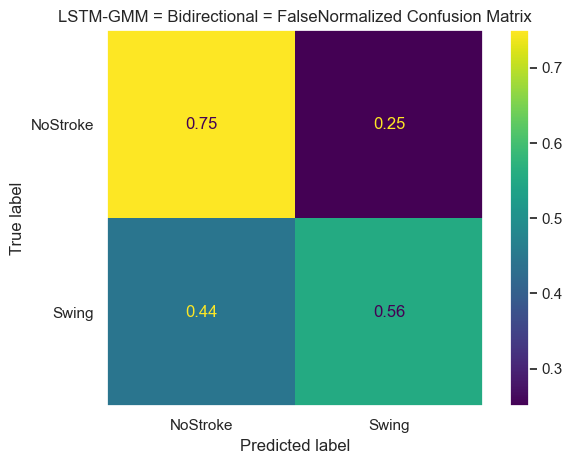

LSTM-GMM_Bidirectional_True.pth
Test Accuracy: 0.867
Test F1 Macro: 0.856


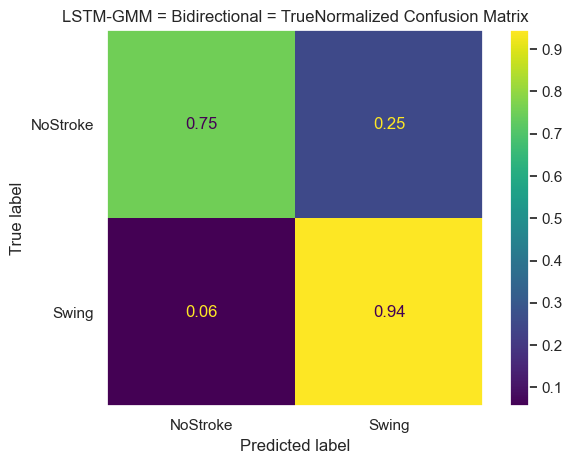

In [48]:
from sklearn.metrics import accuracy_score, f1_score


bi_dict = {
    'LSTM-GMM_Bidirectional_True' : True,
    'LSTM-GMM_Bidirectional_False' : False
}


binary_swing_class_dict = {
    0 : 'Swing',
    1 : 'NoStroke'
}


# For swap out int labels for confusion matrix
class_dict = {index : swing_name for index ,swing_name in enumerate(SWING_TYPES)}


def inference_test_set(test_loader, model):
    ''' Iterate thorugh test set and get model outputs
    Args:
       test_loader () : 
       model () :
    '''
    pred_list = []
    label_list = []
    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            # print(X_batch)
            # a-b
            y_batch = y_batch.to(device, non_blocking=True)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)
            pred_list.extend(preds.cpu().numpy())
            label_list.extend(y_batch.cpu().numpy())

    return pred_list, label_list

    

def get_test_accuracy(pred_list:list, label_list:list, show=True):
    ''' Calculate the accuracy and f1 score of the model on the test set
    Args:

    '''
    test_acc = accuracy_score(label_list, pred_list)
    test_f1  = f1_score(label_list, pred_list, average='macro')
    if show:
        print(f'Test Accuracy: {test_acc:.3f}')
        print(f'Test F1 Macro: {test_f1:.3f}')
    return test_acc, test_f1





def testing_main(test_loader):
    ''' 
    '''
    gp = GraphPlotter('')
    
    create_folder('data/metrics/')

    for model_name in [i for i in os.listdir('data/models/') if 'LSTM-GMM_Bidirectional' in i]:
        print(model_name)
        model = None
        if 'False' in model_name:
            model = LSTMClassifier(input_dim=73, hidden=128, num_classes=4, bidirectional=False)
        else:
            model = LSTMClassifier(input_dim=73, hidden=128, num_classes=4, bidirectional=True)

        model.load_state_dict(torch.load(f'data/models/{model_name}'))
        model.to(device)
        y_pred, label_list = inference_test_set(test_loader, model)

        y_pred_labels = [binary_swing_class_dict[label_int] for label_int in y_pred]
        true_labels = [binary_swing_class_dict[label_int] for label_int in label_list]

        test_acc, test_f1 = get_test_accuracy(y_pred, label_list, show=True)

        gp = GraphPlotter('')
        gp.plot_confusion_matrix(y_pred_labels, true_labels, title=f'{model_name.split(".")[0].replace("_", " = ") }Normalized Confusion Matrix')

        # Get length of each action in test set
        # len_actions_list = [len(x) for x in X_test]
        # gp.plot_len_vs_acc(len_actions_list, y_true=true_labels, y_pred=y_pred_labels)


testing_main(test_loader)



Infer class of swing from combo fo the two models

In [ ]:
# Testin files dict that ill use 
test_files_dict